# Titanic Survival Analysis

## 1. Problem Statement


This project analyzes survival patterns of Titanic passengers using data analysis techniques. The goal is to identify key factors influencing survival such as gender, class, and age.

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

## 2. Data Understanding

In [37]:
print("DATASET OVERVIEW")
print(f"Dataset Shape: {df.shape}")
print(f"Total Rows: {df.shape[0]}") #0 means row
print(f"Total Columns: {df.shape[1]}") #1 means column

DATASET OVERVIEW
Dataset Shape: (891, 12)
Total Rows: 891
Total Columns: 12


In [38]:
print("FIRST 5 ROWS OF DATA")
df.head()

FIRST 5 ROWS OF DATA


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [39]:
print("DATA TYPES")
print(df.dtypes)

DATA TYPES
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [40]:
print("BASIC INFO OF DATASET")
df.info()

BASIC INFO OF DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [41]:
print("MISSING VALUES ANALYSIS")

missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': missing_count.values,
    'Missing_Percentage': missing_percent.values
})
print(missing_df)

MISSING VALUES ANALYSIS
         Column  Missing_Count  Missing_Percentage
0   PassengerId              0            0.000000
1      Survived              0            0.000000
2        Pclass              0            0.000000
3          Name              0            0.000000
4           Sex              0            0.000000
5           Age            177           19.865320
6         SibSp              0            0.000000
7         Parch              0            0.000000
8        Ticket              0            0.000000
9          Fare              0            0.000000
10        Cabin            687           77.104377
11     Embarked              2            0.224467


In [42]:
print("COLUMN NAMES")
for i,col in enumerate (df.columns):
    print(f"{i+1}. {col}")

COLUMN NAMES
1. PassengerId
2. Survived
3. Pclass
4. Name
5. Sex
6. Age
7. SibSp
8. Parch
9. Ticket
10. Fare
11. Cabin
12. Embarked


In [43]:
print("STATISTICAL SUMMARY (NUMERICAL COLUMNS)")
print(df.describe())

STATISTICAL SUMMARY (NUMERICAL COLUMNS)
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


* Missing columns: Age(177), Cabin(687), Embarked(2)
* Important Columns:
                  Sex (VERY important)

                  Pclass (rich vs poor)

                  Age (young vs old)

                  Fare (wealth indicator)

                  Embarked (boarding location)

* Observations :
         Dataset has mix of categorical and numerical features

         Survived is target variable (0 = died, 1 = survived)

         Cabin has too many missing values

         Age has moderate missing - needs fixing
         

## 3. Data Preprocessing and Cleaning

In [44]:
# to check weather it is useful or null 
#how it can help me 
print("DATA PREPROCESSING & CLEANING")
print("\nHandling Missing Values...")

DATA PREPROCESSING & CLEANING

Handling Missing Values...


In [45]:
#fill age with median 
df['Age']=df['Age'].fillna(df['Age'].median())
print("Filled missing age with median")

Filled missing age with median


In [46]:
#drop cabin 
df=df.drop('Cabin',axis=1) #axis = 1 means column not row 
print("Cabin column is dropped")

Cabin column is dropped


In [47]:
#fill embarked with mode 
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0]) #0 means pick first value 
print("Filled missing embarked with mode")

Filled missing embarked with mode


In [48]:
#drop unnecessary columns 
df=df.drop(['Name','Ticket'],axis=1)
print("Unnecessary columns dropped")

Unnecessary columns dropped


In [49]:
print("Again checking for null values")
df.isnull().sum()

Again checking for null values


PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

In [50]:
print("DATA PREPROCESSING & CLEANING DONE")

DATA PREPROCESSING & CLEANING DONE


## 4. Analysis

### Q1: What is survival rate?

In [51]:
print("ANALYSING SURVIVAL RATES.....")
df['Survived'].value_counts()  # 0 ---> dead & 1 ---> survived

ANALYSING SURVIVAL RATES.....


Survived
0    549
1    342
Name: count, dtype: int64

In [52]:
died     = df[df['Survived'] == 0]
survived = df[df['Survived'] == 1]

print(f"Total Died     : {len(died)}")
print(f"Total Survived : {len(survived)}")

Total Died     : 549
Total Survived : 342


In [53]:
df['Survival_Status'] = df['Survived'].map({0: 'Died', 1: 'Survived'}) #add new column easy for visualization

print(df['Survival_Status'].value_counts())

Survival_Status
Died        549
Survived    342
Name: count, dtype: int64


In [54]:
x=df['Survived'].value_counts(normalize=True)*100
print("Require survival and death percentage will be : ")
print(x.round(2))

Require survival and death percentage will be : 
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


Only 38.38% of passengers survived, while 61.62% did not survive, indicating that the majority of people on board the Titanic lost their lives.

This suggests survival was difficult and likely influenced by factors such as gender, class, and age rather than being random.

### Q2: Gender Vs Survival?

In [55]:
print("ANALYSING GENDER VS SURVIVAL.....")
y=df.groupby('Sex')['Survived'].mean()*100
print("Gender vs Survival analysis is as follows: ")
print(y.round(2))

ANALYSING GENDER VS SURVIVAL.....
Gender vs Survival analysis is as follows: 
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64


Females had a much higher survival rate (74.20%) compared to males (18.89%), showing a significant difference in survival outcomes based on gender.

This suggests that women were given priority during rescue operations, reflecting the “women and children first” policy followed during the Titanic evacuation.

### Q3: Class Vs Survival?

In [56]:
print("ANALYSING CLASS VS SURVIVAL.....")
z=df.groupby('Pclass')['Survived'].mean()*100
print("Pclass vs Survival analysis is as follows: ")
print(z.round(2))

ANALYSING CLASS VS SURVIVAL.....
Pclass vs Survival analysis is as follows: 
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64


Passengers in 1st class had the highest survival rate, while those in 3rd class had the lowest survival rate

This likely occurred because higher-class passengers had better access to lifeboats, were closer to upper decks, and received priority during evacuation, whereas lower-class passengers faced more barriers and delays.

### Q4: Gender VS Class?

In [57]:
print("Gender and Class.....")
x1=df.groupby(['Pclass','Sex'])['Survived'].mean()*100
print("require analysis is ")
print(x1.round(2))

Gender and Class.....
require analysis is 
Pclass  Sex   
1       female    96.81
        male      36.89
2       female    92.11
        male      15.74
3       female    50.00
        male      13.54
Name: Survived, dtype: float64


1st class females had the highest survival rate (~96.8%), while 3rd class males had the lowest (~13.5%), showing a huge survival gap based on both gender and class.

Survival was strongly influenced by both gender and class together. Women, especially in higher classes, were given the highest priority, while lower-class men were the least prioritized during evacuation.

### Q5: Age Impact?

In [58]:
print("ANALYSING AGE IMPACT.....")
df.groupby('Survived')['Age'].mean()

ANALYSING AGE IMPACT.....


Survived
0    30.028233
1    28.291433
Name: Age, dtype: float64

The average age of survivors (~28 years) is slightly lower than those who did not survive (~30 years), indicating that younger passengers had a marginally higher chance of survival.

The small difference suggests that age alone was not a major factor in survival, and other variables like gender and class had a much stronger influence

In [59]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins   = [0, 12, 20, 40, 60, 100],
    labels = ['Child', 'Teen', 'Adult', 'Middle Age', 'Senior']
)

print(df.groupby('Age_Group')['Survived'].value_counts())

Age_Group   Survived
Child       1            40
            0            29
Teen        0            68
            1            42
Adult       0           357
            1           205
Middle Age  0            78
            1            50
Senior      0            17
            1             5
Name: count, dtype: int64


C:\Users\hp\AppData\Local\Temp\ipykernel_19820\3230270316.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Age_Group')['Survived'].value_counts())


#### Overall Insight

Survival was not random. It followed a clear priority pattern:
- Females > Males
- Higher class > Lower class
- Children > Adults > Seniors

The strongest factors influencing survival were gender and class, while age had a secondary effect.

## 5. Visualization

SURVIVAL COUNT


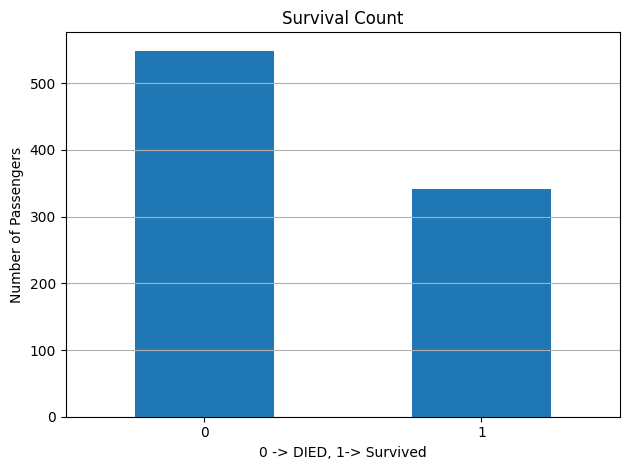

In [60]:
print("SURVIVAL COUNT")
df['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Count")
plt.xlabel("0 -> DIED, 1-> Survived")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout() 
plt.savefig(r"C:\Users\hp\Desktop\Titanic-Survival-Analysis\Images\survival.png")
plt.show()

GENDER VS SURVIVAL


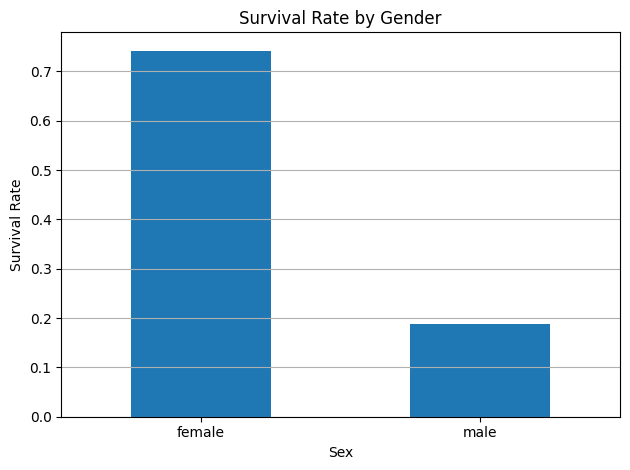

In [61]:
print("GENDER VS SURVIVAL")
df.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout() 
plt.savefig(r"C:\Users\hp\Desktop\Titanic-Survival-Analysis\Images\gender_survival.png")
plt.show()

Female have significantly higher survival rate compared to males, supporting the "women first" evacuation method

CLASS VS SURVIVAL


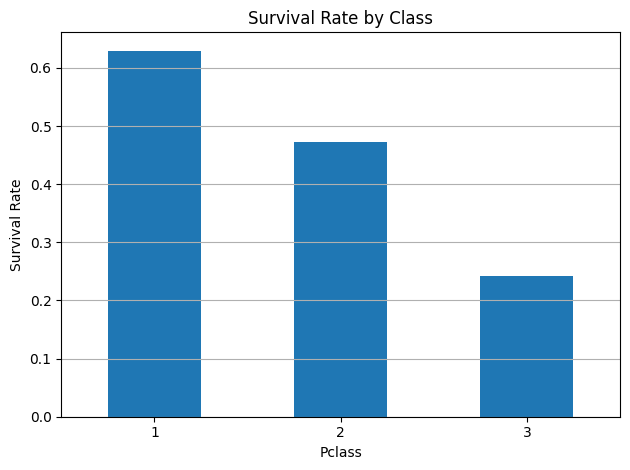

In [62]:
print("CLASS VS SURVIVAL")
df.groupby('Pclass')['Survived'].mean().plot(kind='bar')
plt.title("Survival Rate by Class")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\Titanic-Survival-Analysis\Images\survival_by_class.png")
plt.show()

First-class passengers had higher survival rates likely due to better access to lifeboats and proximity to upper decks during evacuation.

AGE GROUP


C:\Users\hp\AppData\Local\Temp\ipykernel_19820\3845213230.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['Survived'].mean().plot(kind='bar')


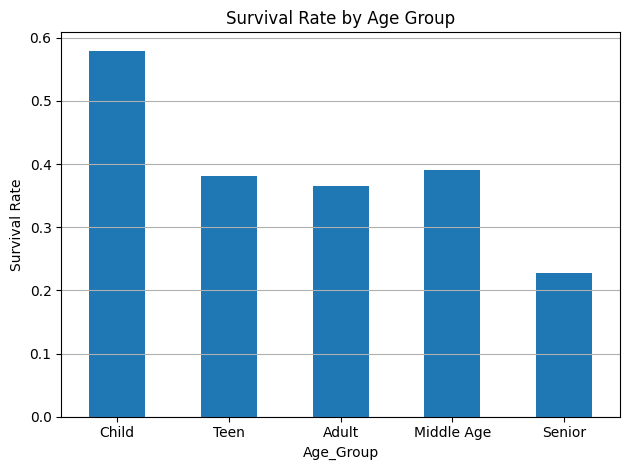

In [63]:
print("AGE GROUP")
df.groupby('Age_Group')['Survived'].mean().plot(kind='bar')
plt.title("Survival Rate by Age Group")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\Titanic-Survival-Analysis\Images\survival_by_age_group.png")
plt.show()

child has more survival all becaus of child and women first policy

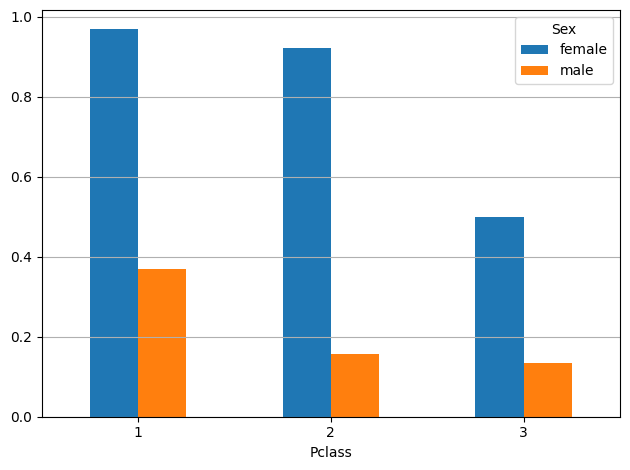

In [64]:
df.groupby(['Pclass','Sex'])['Survived'].mean().unstack().plot(kind='bar')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\Titanic-Survival-Analysis\Images\pclass_and_gender_survival.png")
plt.show()

## 6. Final Insights

1. Only 38% passengers survived, indicating survival was difficult and not random.

2. Females had a much higher survival rate (~74%) compared to males (~19%), showing strong gender-based priority.

3. 1st class passengers had the highest survival rate, while 3rd class had the lowest, indicating class-based inequality in survival.

4. Combining gender and class shows that 1st class females had the highest survival, while 3rd class males had the lowest.

5. Children had a relatively higher survival rate compared to adults and seniors, but age was less influential than gender and class.

### Conclusion

Survival on the Titanic was heavily influenced by social factors such as gender and class rather than being random. Women and higher-class passengers had significantly better chances of survival.